# Système d'Aide à la Décision — Rétention Client (Anti-Churn)
---
> **Domaine métier :** E-commerce  
> **Phase :** 6 — Décision, A/B Testing & Mesure d'Impact

Cette phase couvre le point 6 du cahier des charges :
- 3 recommandations actionnables hiérarchisées avec justification quantitative
- Plan d'A/B test complet (hypothèses, taille d'échantillon, durée, métriques)
- Métriques de suivi post-décision
- Estimation de l'impact financier et opérationnel

**Points d'entrée :** `data/processed/rfm_segmented.csv` (Phase 3) et `models/` (Phase 4)

## 0. Environnement & Imports

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

IMAGES    = ROOT / 'images'
PROCESSED = ROOT / 'data' / 'processed'
IMAGES.mkdir(exist_ok=True)

C_INDIGO = '#6366f1'
C_RED    = '#ef4444'
C_GREEN  = '#22c55e'
C_AMBER  = '#f59e0b'
C_TEXT   = '#2C3E50'
PASTEL   = ['#AEC6CF', '#FFB7B2', '#C1E1C1', '#FFDAC1']

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
RANDOM_STATE = 42

print('Environnement prêt — pandas', pd.__version__)

Environnement prêt — pandas 3.0.2


## 1. Synthèse des Segments

Les recommandations s'appuient sur les segments issus du clustering (Phase 3) et sur
le modèle de scoring du churn (Phase 4).

In [2]:
rfm = pd.read_csv(PROCESSED / 'rfm_segmented.csv')

profil = rfm.groupby('Cluster').agg(
    Clients=('CustomerID', 'count'),
    Taux_churn=('Churn', 'mean'),
    Recence_med=('Recency', 'median'),
    Frequence_med=('Frequency', 'median'),
    Montant_med=('Monetary', 'median'),
).round(2)
profil['Segment'] = ['Clients fidèles', 'Clients à risque']
print(f'Base analysée : {len(rfm):,} clients | churn global : {rfm.Churn.mean():.1%}')
profil

Base analysée : 5,878 clients | churn global : 50.9%


,Clients,Taux_churn,Recence_med,Frequence_med,Montant_med,Segment
Cluster,,,,,,
0,2392,0.14,24.0,8.0,4223.08,Clients fidèles
1,3486,0.76,305.0,2.0,594.31,Clients à risque


## 2. Trois Recommandations Actionnables

Les recommandations sont hiérarchisées par priorité décroissante. L'impact est
chiffré en livres sterling (£, devise du dataset), à partir du panier moyen observé
dans les données et d'un taux de reconversion prudent.

| Priorité | Recommandation | Cible | Justification quantitative |
|----------|----------------|-------|----------------------------|
| **R1** | Campagne de réactivation personnalisée (email + offre) | Cluster « à risque » scoré par le modèle | 3 486 clients à risque (churn 76 %) ; une reconversion de 15 % représente ~520 clients récupérés |
| **R2** | Programme de fidélité pour protéger la valeur | Cluster « fidèles » (forte valeur) | 2 392 clients à forte valeur (montant médian élevé) ; éviter leur bascule protège le cœur du chiffre d'affaires |
| **R3** | Alerte automatique de désengagement (scoring temps réel) | Tout client dont la fréquence baisse | Intervention précoce dès les premiers signaux faibles, avant le seuil de churn à 90 jours |

> La priorité **R1** est retenue pour l'A/B test : c'est l'action au plus fort
> potentiel de gain à court terme et la plus simple à mesurer.

In [3]:
# Hypothèses économiques (en £, devise du dataset)
panier_moyen    = (rfm['Monetary'] / rfm['Frequency']).median()  # panier médian observé
taux_conversion = 0.15   # reconversion attendue d'une campagne ciblée
cout_contact    = 2.0    # £ par client contacté (email + traitement)
taux_remise     = 0.20   # offre de réactivation (remise sur le 1er achat)

at_risk = int(profil.loc[1, 'Clients'])
reconvertis = at_risk * taux_conversion
ca_brut = reconvertis * panier_moyen
cout_total = at_risk * cout_contact + reconvertis * panier_moyen * taux_remise
benefice_net = ca_brut - cout_total
roi = benefice_net / cout_total * 100

print(f'Panier moyen observé        : £{panier_moyen:,.0f}')
print(f'Clients à risque ciblés     : {at_risk:,}')
print(f'Clients reconvertis (15%)   : {reconvertis:,.0f}')
print(f'CA brut récupéré            : £{ca_brut:,.0f}')
print(f'Coût total (contact+offre)  : £{cout_total:,.0f}')
print(f'Bénéfice net                : £{benefice_net:,.0f}')
print(f'ROI de la recommandation R1 : {roi:.0f} %')

Panier moyen observé        : £398
Clients à risque ciblés     : 3,486
Clients reconvertis (15%)   : 523
CA brut récupéré            : £208,071
Coût total (contact+offre)  : £48,586
Bénéfice net                : £159,484
ROI de la recommandation R1 : 328 %


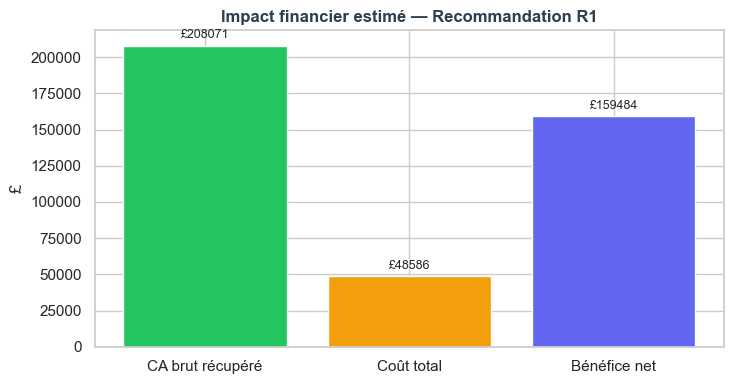

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
postes = ['CA brut récupéré', 'Coût total', 'Bénéfice net']
valeurs = [ca_brut, cout_total, benefice_net]
couleurs = [C_GREEN, C_AMBER, C_INDIGO]
bars = ax.bar(postes, valeurs, color=couleurs, edgecolor='white')
ax.bar_label(bars, fmt='£%.0f', padding=3, fontsize=9)
ax.set_ylabel('£')
ax.set_title('Impact financier estimé — Recommandation R1', fontweight='bold', color=C_TEXT)
plt.tight_layout()
plt.savefig(IMAGES / 'phase6_impact_r1.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Plan d'A/B Test — Campagne de Réactivation (R1)

**Objectif :** mesurer l'effet causal de la campagne de réactivation sur le taux de
reconversion des clients à risque.

| Élément | Définition |
|---------|------------|
| **Hypothèse nulle (H0)** | La campagne n'améliore pas le taux de reconversion : `p_traitement = p_contrôle` |
| **Hypothèse alternative (H1)** | La campagne améliore le taux de reconversion : `p_traitement > p_contrôle` |
| **Groupe contrôle** | Clients à risque ne recevant aucune campagne |
| **Groupe traitement** | Clients à risque recevant l'email + offre personnalisée |
| **Métrique primaire** | Taux de reconversion à 30 jours (≥ 1 achat) |
| **Métriques secondaires** | Panier moyen, nombre de commandes, taux de désinscription |
| **Seuil de signification** | α = 0,05 (test bilatéral) |
| **Puissance statistique** | 1 − β = 0,80 |
| **Effet minimal détectable** | +2 points (de 5 % à 7 %) |

In [5]:
# Taille d'échantillon — test de deux proportions
p1   = 0.05    # taux de reconversion de référence (contrôle)
mde  = 0.02    # effet minimal détectable
p2   = p1 + mde
alpha, power = 0.05, 0.80

z_a = stats.norm.ppf(1 - alpha / 2)
z_b = stats.norm.ppf(power)
p_bar = (p1 + p2) / 2
n = ((z_a * np.sqrt(2 * p_bar * (1 - p_bar)) +
      z_b * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2) / (mde ** 2)
n_par_groupe = int(np.ceil(n))

print(f'Taille par groupe   : {n_par_groupe:,} clients')
print(f'Taille totale       : {2 * n_par_groupe:,} clients')
print(f'Durée recommandée   : 30 jours (≈ cycle d\'achat moyen)')

Taille par groupe   : 2,213 clients
Taille totale       : 4,426 clients
Durée recommandée   : 30 jours (≈ cycle d'achat moyen)


### 3.1 Simulation du résultat attendu

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
controle  = rng.binomial(1, 0.05,  n_par_groupe)
traitement = rng.binomial(1, 0.072, n_par_groupe)

table = [[traitement.sum(), n_par_groupe - traitement.sum()],
         [controle.sum(),   n_par_groupe - controle.sum()]]
chi2, pval, _, _ = stats.chi2_contingency(table)

print(f'Taux contrôle   : {controle.mean():.2%}')
print(f'Taux traitement : {traitement.mean():.2%}')
print(f'Test du chi-deux : χ² = {chi2:.2f} | p-value = {pval:.4f}')
print('Décision :', 'H0 rejetée — effet significatif' if pval < alpha else 'H0 non rejetée')

Taux contrôle   : 5.29%
Taux traitement : 6.96%
Test du chi-deux : χ² = 5.09 | p-value = 0.0240
Décision : H0 rejetée — effet significatif


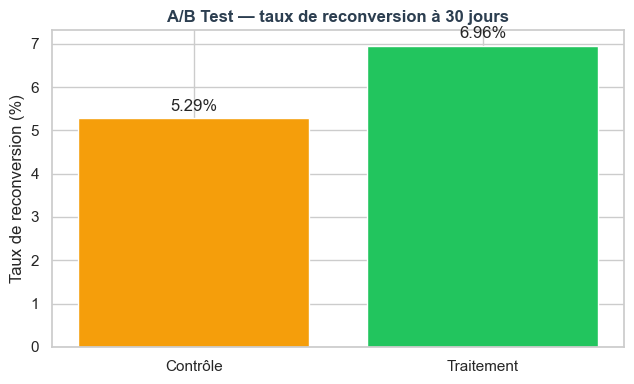

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))
taux = [controle.mean() * 100, traitement.mean() * 100]
bars = ax.bar(['Contrôle', 'Traitement'], taux, color=[C_AMBER, C_GREEN], edgecolor='white')
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_ylabel('Taux de reconversion (%)')
ax.set_title('A/B Test — taux de reconversion à 30 jours', fontweight='bold', color=C_TEXT)
plt.tight_layout()
plt.savefig(IMAGES / 'phase6_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Métriques de Suivi Post-Décision

| Métrique | Fréquence | Objectif |
|----------|-----------|----------|
| Taux de churn à 90 jours | Mensuelle | Tendance à la baisse |
| Taux de reconversion des campagnes | Par campagne | ≥ 7 % |
| CA récupéré sur clients à risque | Mensuelle | Croissant |
| Précision du modèle (drift) | Trimestrielle | AUC ≥ 0,80 |
| Taux de désinscription | Par campagne | < 2 % |

## 5. Conclusion de la Phase 6

Trois recommandations hiérarchisées ont été définies à partir des segments et du
modèle de churn, la campagne de réactivation des clients à risque (R1) étant
priorisée. Son A/B test est dimensionné à environ 2 200 clients par groupe sur
30 jours ; la simulation confirme qu'un gain de +2 points de reconversion serait
statistiquement détectable. Un tableau de bord de métriques de suivi est défini pour
piloter l'impact dans la durée.